# Лабораторная работа 1: «Метод обратного распространения ошибки»
Выполнил: Ермолаев Илья группа 3823М1ФИии2

In [1]:
# Установка Kaggle API
!pip install kaggle

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gzip
import struct
import time
from array import array
from os.path  import join
%matplotlib inline
import random
import matplotlib.pyplot as plt

In [3]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

Загружаем данные MNIST датасета из Kaggle

In [4]:
# Скачивание датасета MNIST с Kaggle
!kaggle datasets download -d hojjatk/mnist-dataset

# Распаковка архива
!unzip mnist-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/hojjatk/mnist-dataset
License(s): copyright-authors
mnist-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  mnist-dataset.zip
replace t10k-images-idx3-ubyte/t10k-images-idx3-ubyte? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: t10k-images-idx3-ubyte/t10k-images-idx3-ubyte  
  inflating: t10k-images.idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte  
  inflating: t10k-labels.idx1-ubyte  
  inflating: train-images-idx3-ubyte/train-images-idx3-ubyte  
  inflating: train-images.idx3-ubyte  
  inflating: train-labels-idx1-ubyte/train-labels-idx1-ubyte  
  inflating: train-labels.idx1-ubyte  


Считываем MNIST dataset

In [5]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (np.array(x_train), np.array(y_train)),(np.array(x_test), np.array(y_test))

Прописываем пути до изображений

In [6]:
training_images_filepath = 'train-images-idx3-ubyte/train-images-idx3-ubyte'
training_labels_filepath = 'train-labels-idx1-ubyte/train-labels-idx1-ubyte'
test_images_filepath = 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte'
test_labels_filepath = 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte'

In [7]:
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(X_train, y_train), (X_test, y_test) = mnist_dataloader.load_data()

Нормализуем данные:

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Выведем несколько изображений цифр из тренировочной и тестовой выборок:

In [9]:
def print_img(images, labels):
  plt.figure(figsize=(10, 5))
  fig, axes = plt.subplots(5, 5, figsize=(10, 5))
  for i in range(25):
    row, col = divmod(i, 5)
    ax = axes[row, col]
    ax.imshow(images[i], cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Цифра: {labels[i]}", fontsize=10, color='black')
  plt.tight_layout()
  plt.show()

Изображения тренировочной выборки:

<Figure size 1000x500 with 0 Axes>

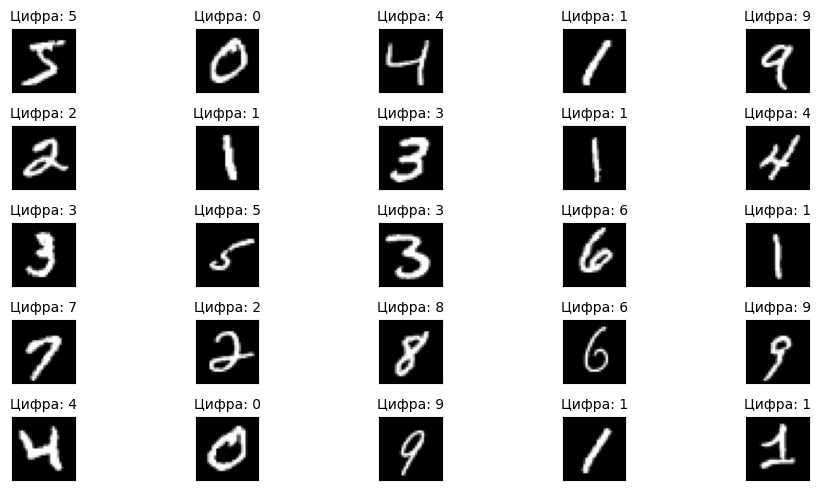

In [10]:
print_img(X_train, y_train)

Изображения тестовой выборки:

<Figure size 1000x500 with 0 Axes>

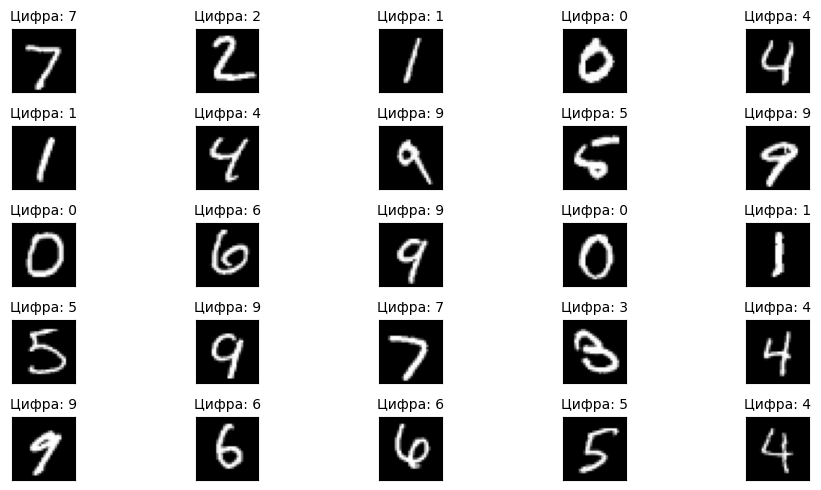

In [11]:
print_img(X_test, y_test)

In [12]:
X_train.shape

(60000, 28, 28)

Преобразуем в одномерные вектора

In [13]:
X_train = X_train.reshape(X_train.shape[0], -1)  # Shape: (60000, 784)
X_test = X_test.reshape(X_test.shape[0], -1)    # Shape: (10000, 784)

In [14]:
X_train.shape

(60000, 784)

Инициализируем параметры сети:

In [15]:
# Инициализация параметров сети (Весов и смещений)
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    Wi = np.random.randn(hidden_size, input_size) * np.sqrt(1. / input_size)
    bi = np.zeros((hidden_size, 1))
    Wh = np.random.randn(output_size, hidden_size) * np.sqrt(1. / hidden_size)
    bh = np.zeros((output_size, 1))
    return Wi, bi, Wh, bh

input_size = 784
# Кол-во скрытых нейронов
hidden_size = 300
# 10 классов (0, 9)
output_size = 10

W1, b1, W2, b2 = initialize_parameters(input_size, hidden_size, output_size)

Введем определение функций активации. На скрытом слое будем использовать ReLU, на выходном - softmax. В качестве функции ошибки будем использовать кросс-энтропию.

In [16]:
# Функция активации для скрытого слоя
def relu(Z):
    return np.maximum(0, Z)

# Производная функции ReLU для обратного распространения ошибки
def relu_derivative(Z):
    return Z > 0

# Функция softmax для выхода модели
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z))
    return exp_Z / exp_Z.sum(axis=0, keepdims=True)

# Прямое распространение
def forward_propagation(X, Wih, bh, Who, bo):
    # Преобразуем входной слой в скрытый
    lhi = np.dot(Wih, X.T) + bh
    lho = relu(lhi)
    # Преобразуем скрытый слой в выходной
    loi = np.dot(Who, lho) + bo
    out_probs = softmax(loi)
    return lhi, lho, loi, out_probs

# Функция потерь - кросс-энтропия
def compute_loss(predicted, true_labels):
    m = true_labels.shape[0]
    log_probs = np.log(predicted[true_labels, range(m)])
    loss = -np.sum(log_probs) / m
    return loss

# Обратное распространение
def backward_propagation(X, Y, Z1, A1, Z2, A2, W1, b1, W2, b2):
    m = Y.shape[0]

    # Вычисляем градиент функции ошибки по выходному слою
    # (Можно было бы использовать one-hot представление но так более явно)
    dZ2 = A2
    dZ2[Y, range(m)] -= 1
    dZ2 /= m

    dW2 = np.dot(dZ2, A1.T)
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(dZ1, X)
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

# Обновление весов и смещений
def update_parameters(Wi, bi, Wh, bh, dWi, dbi, dWh, dbh, learning_rate):
    Wi -= learning_rate * dWi
    bi -= learning_rate * dbi
    Wh -= learning_rate * dWh
    bh -= learning_rate * dbh
    return Wi, bi, Wh, bh


In [17]:
def train(X, Y, W1, b1, W2, b2, learning_rate, epochs, batch_size):
    m = X.shape[0]
    for epoch in range(epochs):
        epoch_start_time = time.time()
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        Y_shuffled = Y[permutation]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            Y_batch = Y_shuffled[i:i+batch_size]

            Z1, A1, Z2, A2 = forward_propagation(X_batch, W1, b1, W2, b2)
            loss = compute_loss(A2, Y_batch)
            dW1, db1, dW2, db2 = backward_propagation(X_batch, Y_batch, Z1, A1, Z2, A2, W1, b1, W2, b2)
            W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        epoch_end_time = time.time()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f} Time: {epoch_end_time - epoch_start_time:.2f}s")

    return W1, b1, W2, b2

learning_rate = 0.1
epochs = 20
batch_size = 64

W1, b1, W2, b2 = train(X_train, y_train, W1, b1, W2, b2, learning_rate, epochs, batch_size)

Epoch 1/20, Loss: 0.2661 Time: 8.78s
Epoch 2/20, Loss: 0.1704 Time: 3.86s
Epoch 3/20, Loss: 0.1413 Time: 3.73s
Epoch 4/20, Loss: 0.0880 Time: 5.61s
Epoch 5/20, Loss: 0.0307 Time: 3.68s
Epoch 6/20, Loss: 0.0390 Time: 3.67s
Epoch 7/20, Loss: 0.0250 Time: 5.96s
Epoch 8/20, Loss: 0.0708 Time: 3.68s
Epoch 9/20, Loss: 0.0264 Time: 3.70s
Epoch 10/20, Loss: 0.0531 Time: 5.63s
Epoch 11/20, Loss: 0.0279 Time: 3.63s
Epoch 12/20, Loss: 0.0189 Time: 3.69s
Epoch 13/20, Loss: 0.0229 Time: 5.59s
Epoch 14/20, Loss: 0.0689 Time: 3.71s
Epoch 15/20, Loss: 0.0246 Time: 3.73s
Epoch 16/20, Loss: 0.0033 Time: 5.46s
Epoch 17/20, Loss: 0.0213 Time: 3.62s
Epoch 18/20, Loss: 0.0067 Time: 3.71s
Epoch 19/20, Loss: 0.0180 Time: 5.61s
Epoch 20/20, Loss: 0.0367 Time: 3.76s


In [18]:
def predict(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return np.argmax(A2, axis=0)

y_pred = predict(X_test, W1, b1, W2, b2)
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 98.08%
